# Tabular Q-Learning vs SARSA on Taxi-v3

**Q-Learning** (off-policy): uses the greedy max-Q bootstrap regardless of what action is actually taken.

**SARSA** (on-policy): bootstraps from the action that was *actually* selected by the current ε-greedy policy — so the Q-values directly reflect the policy being followed, including its exploration noise.

Both share the same ε-greedy exploration and the same hyperparameters. The only difference is one line: the TD target.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import gymnasium as gym
from collections import defaultdict
from scipy.ndimage import uniform_filter1d   # for smooth learning curves

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## Hyperparameters

In [2]:
# ── shared hyperparams ───────────────────────────────────────────────────────
N_EPISODES   = 5000
ALPHA        = 0.1          # learning rate
GAMMA        = 0.99         # discount
EPS_START    = 1.0
EPS_END      = 0.05
EPS_DECAY    = 0.9995       # multiplicative decay per episode

N_STATES     = 500
N_ACTIONS    = 6

EVAL_EVERY   = 100          # evaluate greedy policy every N episodes
EVAL_EPS     = 20           # episodes per evaluation rollout

## Agent implementations

The only structural difference is the TD target:
- **Q-learning**: `r + γ · max_a' Q(s', a')`  
- **SARSA**: `r + γ · Q(s', a')` where `a'` is sampled from the current ε-greedy policy

In [ ]:
class TabularAgent:
    """Base tabular agent. Subclasses override `td_target`."""

    def __init__(self, n_states, n_actions, alpha, gamma, eps_start, eps_end, eps_decay):
        self.Q         = np.zeros((n_states, n_actions))
        self.alpha     = alpha
        self.gamma     = gamma
        self.eps       = eps_start
        self.eps_end   = eps_end
        self.eps_decay = eps_decay
        self.n_actions = n_actions

    def select_action(self, state, greedy=False):
        if not greedy and np.random.rand() < self.eps:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, s, a, r, s_next, a_next, done):
        target = r if done else r + self.gamma * self.td_target(s_next, a_next)
        self.Q[s, a] += self.alpha * (target - self.Q[s, a])

    def td_target(self, s_next, a_next):
        raise NotImplementedError

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


class QLearningAgent(TabularAgent):
    """Off-policy: bootstrap from the greedy action (max Q), not the taken action."""
    def td_target(self, s_next, a_next):
        return np.max(self.Q[s_next])       # a_next is ignored

# SARSA stands for State → Action → Reward → State → Action
class SARSAAgent(TabularAgent):
    """On-policy: bootstrap from the action actually selected by the ε-greedy policy."""
    def td_target(self, s_next, a_next):
        return self.Q[s_next, a_next]       # uses the real next action

## Training loop

In [4]:
def evaluate(agent, n_episodes=EVAL_EPS):
    """Run greedy policy, return mean reward."""
    env = gym.make('Taxi-v3')
    total = 0.0
    for _ in range(n_episodes):
        s, _ = env.reset()
        done = False
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            done = term or trunc
            total += r
    env.close()
    return total / n_episodes


def train(AgentClass, seed=42):
    np.random.seed(seed)
    env = gym.make('Taxi-v3')
    agent = AgentClass(
        N_STATES, N_ACTIONS, ALPHA, GAMMA, EPS_START, EPS_END, EPS_DECAY
    )

    episode_rewards = []    # raw per-episode reward
    eval_rewards    = []    # greedy policy eval every EVAL_EVERY episodes
    eps_history     = []    # epsilon at episode start
    q_delta_history = []    # mean |ΔQ| per episode (convergence proxy)
    state_visits    = np.zeros(N_STATES, dtype=int)

    for ep in range(N_EPISODES):
        s, _ = env.reset(seed=seed + ep)
        a    = agent.select_action(s)
        ep_reward  = 0.0
        ep_q_delta = 0.0
        steps      = 0
        done       = False

        eps_history.append(agent.eps)

        while not done:
            s_next, r, term, trunc, _ = env.step(a)
            done   = term or trunc
            a_next = agent.select_action(s_next)  # SARSA uses this; Q-learning ignores it

            q_before = agent.Q[s, a]
            agent.update(s, a, r, s_next, a_next, done)
            ep_q_delta += abs(agent.Q[s, a] - q_before)

            state_visits[s] += 1
            s, a = s_next, a_next
            ep_reward += r
            steps     += 1

        agent.decay_epsilon()
        episode_rewards.append(ep_reward)
        q_delta_history.append(ep_q_delta / max(steps, 1))

        if (ep + 1) % EVAL_EVERY == 0:
            eval_rewards.append(evaluate(agent))

    env.close()
    return {
        'agent':           agent,
        'episode_rewards': np.array(episode_rewards),
        'eval_rewards':    np.array(eval_rewards),
        'eps_history':     np.array(eps_history),
        'q_delta':         np.array(q_delta_history),
        'state_visits':    state_visits,
    }


print('Training Q-Learning...')
ql = train(QLearningAgent)
print(f'  Final greedy reward: {ql["eval_rewards"][-1]:.2f}')

print('Training SARSA...')
sarsa = train(SARSAAgent)
print(f'  Final greedy reward: {sarsa["eval_rewards"][-1]:.2f}')

Training Q-Learning...


  Final greedy reward: 8.00
Training SARSA...


  Final greedy reward: 8.85


## Plot 1 — Learning Curves

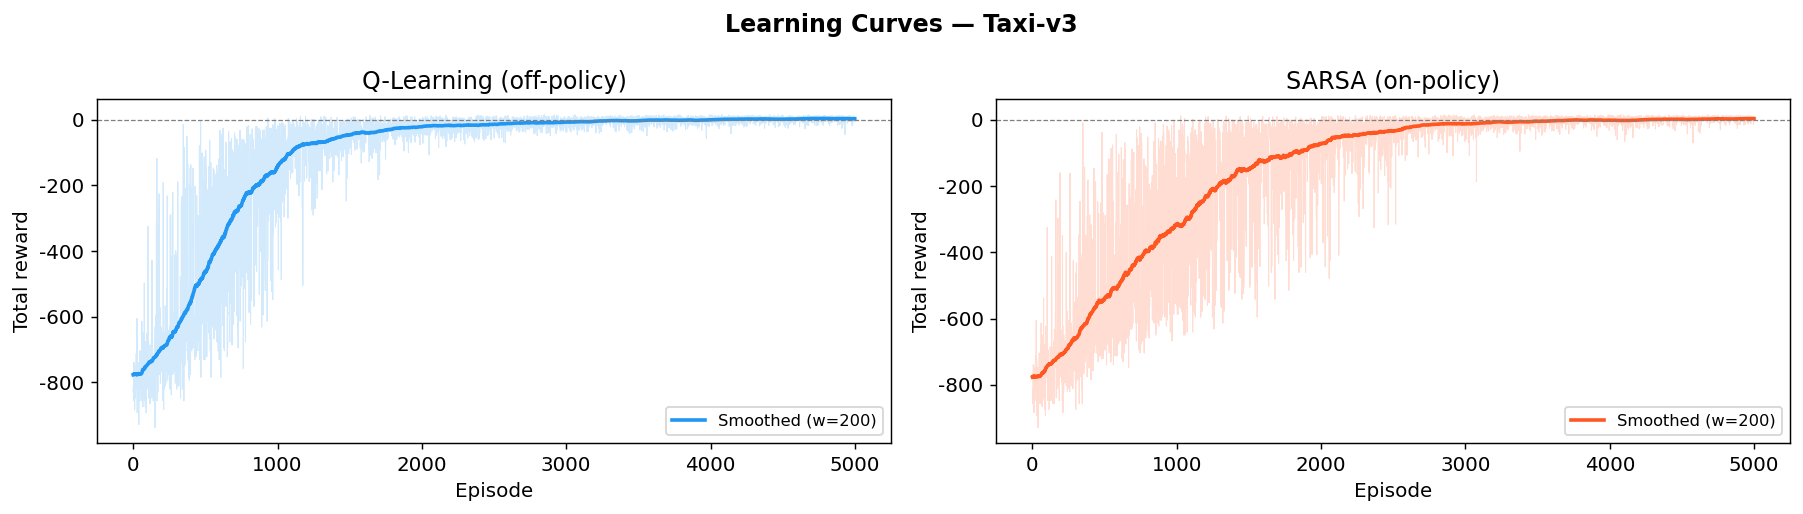

In [5]:
SMOOTH = 200   # window for rolling mean

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
fig.suptitle('Learning Curves — Taxi-v3', fontweight='bold')

for ax, res, label, color in zip(
    axes,
    [ql, sarsa],
    ['Q-Learning (off-policy)', 'SARSA (on-policy)'],
    ['#2196F3', '#FF5722']
):
    raw  = res['episode_rewards']
    smth = uniform_filter1d(raw, size=SMOOTH)
    ax.plot(raw,  alpha=0.2, color=color, linewidth=0.6)
    ax.plot(smth, color=color, linewidth=2.0, label=f'Smoothed (w={SMOOTH})')
    ax.set_title(label)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total reward')
    ax.legend(fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

## Plot 2 — Greedy Policy Evaluation (every 100 episodes)

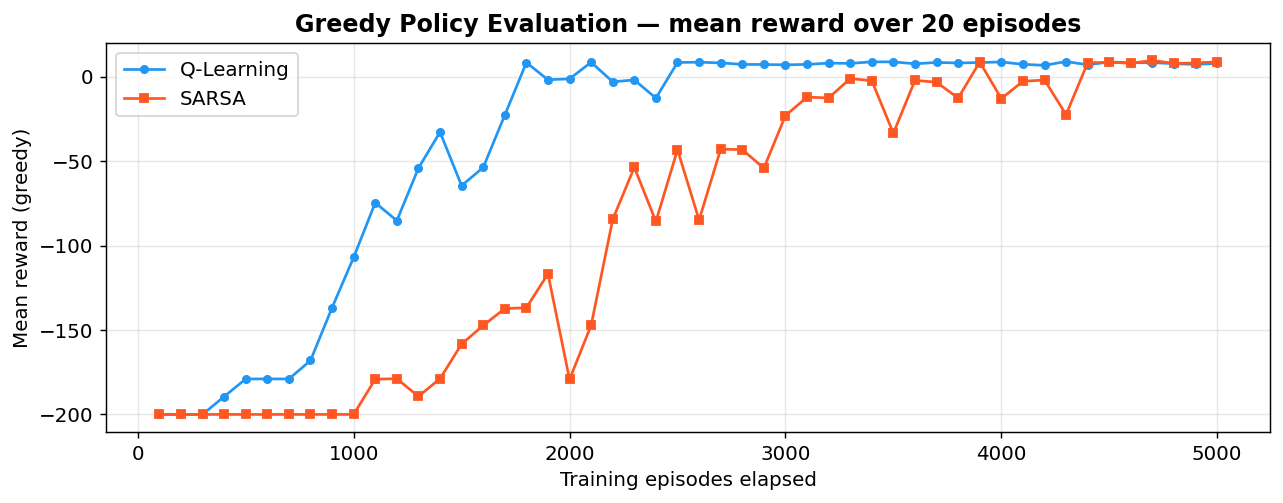

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(1, len(ql['eval_rewards']) + 1) * EVAL_EVERY

ax.plot(x, ql['eval_rewards'],    marker='o', markersize=4, color='#2196F3', label='Q-Learning')
ax.plot(x, sarsa['eval_rewards'], marker='s', markersize=4, color='#FF5722', label='SARSA')
ax.set_title('Greedy Policy Evaluation — mean reward over 20 episodes', fontweight='bold')
ax.set_xlabel('Training episodes elapsed')
ax.set_ylabel('Mean reward (greedy)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 3 — Q-Table Convergence (mean |ΔQ| per episode)

Measures average magnitude of Q-value updates per step. Converging to 0 means the table has stabilised.

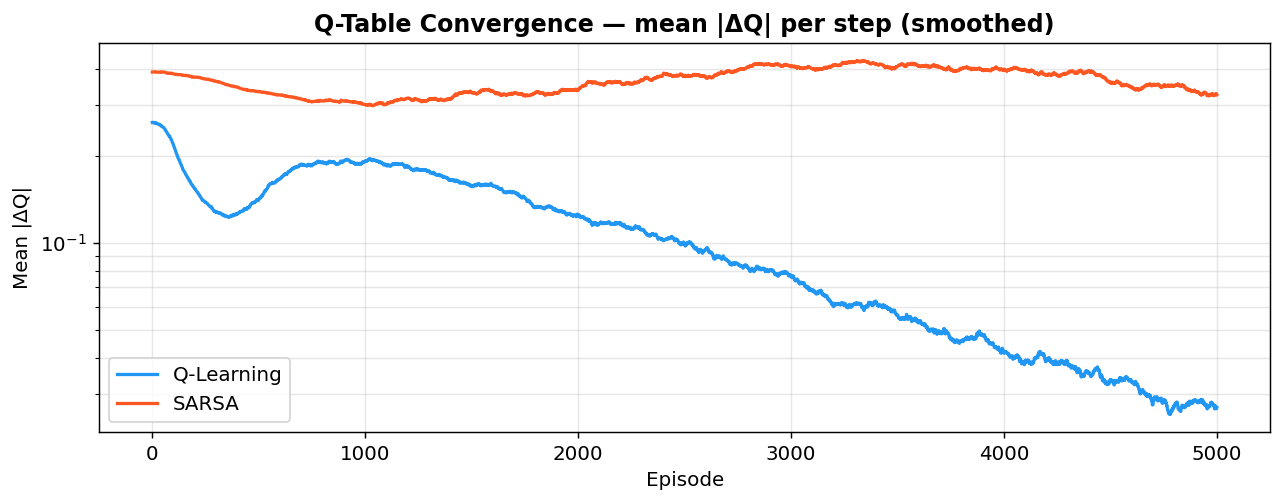

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

for res, label, color in [
    (ql,    'Q-Learning', '#2196F3'),
    (sarsa, 'SARSA',      '#FF5722')
]:
    smth = uniform_filter1d(res['q_delta'], size=200)
    ax.plot(smth, color=color, linewidth=1.8, label=label)

ax.set_title('Q-Table Convergence — mean |ΔQ| per step (smoothed)', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Mean |ΔQ|')
ax.legend()
ax.set_yscale('log')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Plot 4 — Epsilon Decay Schedule

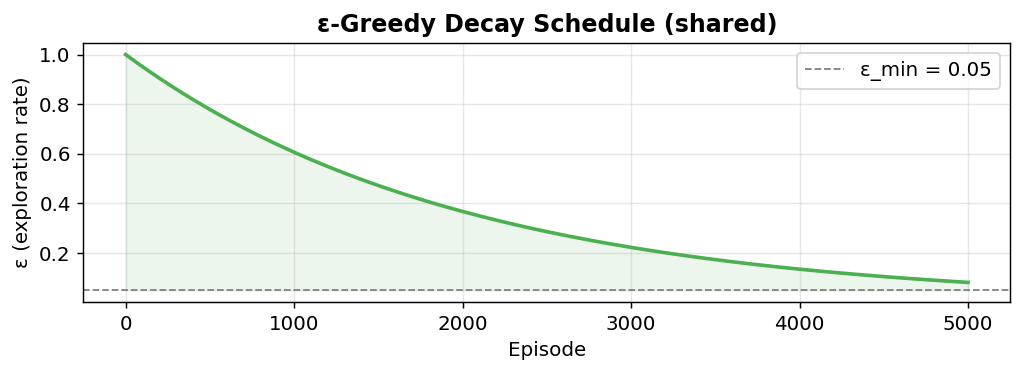

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
# Both agents share the same schedule, so plot once
ax.plot(ql['eps_history'], color='#4CAF50', linewidth=2)
ax.axhline(EPS_END, color='gray', linestyle='--', linewidth=1, label=f'ε_min = {EPS_END}')
ax.fill_between(range(N_EPISODES), ql['eps_history'], EPS_END, alpha=0.1, color='#4CAF50')
ax.set_title('ε-Greedy Decay Schedule (shared)', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('ε (exploration rate)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 5 — State Visit Heatmaps

Taxi-v3 state = `encode(taxi_row, taxi_col, passenger_loc, destination)`.  
We marginalise over passenger/destination to get a 5×5 taxi position grid.

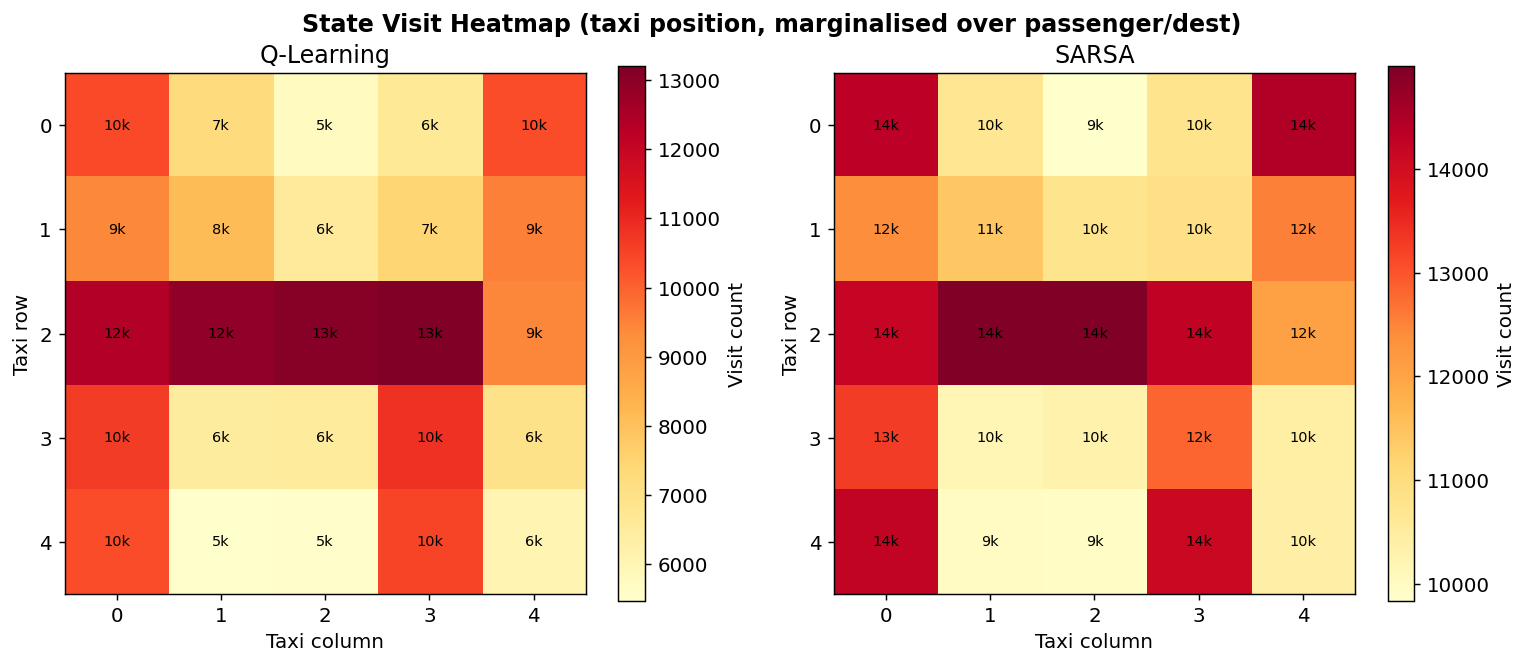

In [9]:
def visits_to_grid(state_visits):
    """Sum visits across passenger_loc (5 values) × dest (4 values) → 5×5 taxi grid."""
    grid = np.zeros((5, 5))
    for state, count in enumerate(state_visits):
        # Taxi-v3 encodes state as: state = ((taxi_row*5 + taxi_col)*5 + passenger)*4 + dest
        dest         = state % 4
        remainder    = state // 4
        passenger    = remainder % 5
        remainder    = remainder // 5
        taxi_col     = remainder % 5
        taxi_row     = remainder // 5
        grid[taxi_row, taxi_col] += count
    return grid


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('State Visit Heatmap (taxi position, marginalised over passenger/dest)',
             fontweight='bold')

for ax, res, title in zip(
    axes,
    [ql, sarsa],
    ['Q-Learning', 'SARSA']
):
    grid = visits_to_grid(res['state_visits'])
    im   = ax.imshow(grid, cmap='YlOrRd', aspect='equal')
    fig.colorbar(im, ax=ax, label='Visit count')
    ax.set_title(title)
    ax.set_xlabel('Taxi column')
    ax.set_ylabel('Taxi row')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    # Annotate each cell
    for r in range(5):
        for c in range(5):
            ax.text(c, r, f'{int(grid[r,c]/1000)}k', ha='center', va='center',
                    fontsize=8, color='black')

plt.tight_layout()
plt.show()

## Summary Table

In [10]:
def summary(res, name):
    last500 = res['episode_rewards'][-500:]
    return {
        'Algorithm':              name,
        'Mean reward (last 500)': f"{last500.mean():.2f}",
        'Std (last 500)':         f"{last500.std():.2f}",
        'Final greedy reward':    f"{res['eval_rewards'][-1]:.2f}",
        'Final mean |ΔQ|':        f"{res['q_delta'][-100:].mean():.6f}",
    }

import pandas as pd
df = pd.DataFrame([summary(ql, 'Q-Learning'), summary(sarsa, 'SARSA')])
df.set_index('Algorithm', inplace=True)
df

,Mean reward (last 500),Std (last 500),Final greedy reward,Final mean |ΔQ|
Algorithm,,,,
Q-Learning,3.03,7.90,8.00,0.026822
SARSA,2.33,8.91,8.85,0.323132
